# Blood Rheology: t-ETV Model Analysis and Visualization
by th
## Overview
The **thermodynamic Extended Thixotropic Vector (t-ETV) model** is a rheological model that describes blood behavior using three structural variables:

1. **Cellular conformation tensor** ($\mathbf{c}^C$): Describes the deformation and orientation of individual red blood cells
2. **Rouleaux conformation tensor** ($\mathbf{c}^R$): Describes the deformation and orientation of cell aggregates (rouleaux formations)
3. **Structure parameter** ($\lambda$): Quantifies the degree of aggregation, ranging from 0 (fully dispersed) to 1 (fully aggregated)

These three variables evolve according to the governing equations presented below, and together they determine the blood's rheological response to applied shear flows.

## Workflow
In the following cells, we will: (1) derive and symbolically construct the t-ETV model equations using SymPy, (2) lambdify the equations to obtain efficient numerical functions, (3) solve the resulting differential equations via time integration, and (4) generate comprehensive visualizations and store the results for multiple shear rates to characterize the model's predictions.

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from extras import show 

sp.init_printing()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}\usepackage{amsmath}"
})

## 1. Symbolic Construction

We define the symbolic variables that will be used throughout the model:

- **Independent variable**: time $t$
- **Imposed shear rate**: $\dot{\gamma}_0$ (constant for simple shear flow startup)
- **State variables**: components of the conformation tensors ($c^C_{ij}$, $c^R_{ij}$) and the structure parameter ($\lambda$)
- **Model parameters**: material constants governing viscosity, elasticity, and structural evolution

In [2]:
# --- independent variable and imposed shear rate ---
t = sp.symbols('t', real=True)
gamma0 = sp.symbols(r'\dot{\gamma_0}', real=True)   # dot(gamma)_0, constant (simple shear startup)

# --- state: components of conformation tensors + lambda ---
cCxx, cCxy, cCyy, cCzz = sp.symbols(r'c^C_{xx} c^C_{xy} c^C_{yy} c^C_{zz}', real=True)
cRxx, cRxy, cRyy, cRzz = sp.symbols(r'c^R_{xx} c^R_{xy} c^R_{yy} c^R_{zz}', real=True)
lam = sp.symbols(r'\lambda', positive=True)

state_syms = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam)

# --- model parameters ---
G_C, muC0, muCinf, tauC             = sp.symbols(r'G_C \mu_{0-c} \mu_{\infty-C} \tau_C', positive=True)
G_R, muR                            = sp.symbols(r'G_R \mu_R', positive=True)
m                                   = sp.symbols('m', positive=True)
tau_lam, tau_break, tau_aggr, dexp  = sp.symbols(r'\tau_\lambda \tau_{break} \tau_{aggr} d', positive=True)
rho, Temp                           = sp.symbols('rho T', positive=True)

param_syms = (G_C, muC0, muCinf, tauC, G_R, muR, m, tau_lam, tau_break, tau_aggr, dexp, rho, Temp)

### Cellular Viscosity (Cross-like Model)

The viscosity of the cellular contribution follows a shear-rate-dependent (shear-thinning) model:

$$\eta_C(\dot{\gamma}_0) = \mu_{C,\infty} + \frac{\mu_{C,0} - \mu_{C,\infty}}{1 + \tau_C \dot{\gamma}_0}$$

where $\mu_{C,0}$ is the zero-shear viscosity, $\mu_{C,\infty}$ is the infinite-shear viscosity, and $\tau_C$ is the relaxation time.

In [3]:
# Viscosity non-linear (Cross-like) for individual cellular contribution
eta_C = muCinf + (muC0 - muCinf)/(1 + tauC*gamma0)

show(eta_C)

<IPython.core.display.Math object>

### Structural Evolution Equation

The structure parameter $\lambda$ evolves phenomenologically according to:

$$\frac{d\lambda}{dt} = \frac{1}{\tau_\lambda} \left[ -\lambda \tau_{\rm break} |\dot{\gamma}_0| + (1-\lambda)|\tau_{\rm aggr}\dot{\gamma}_0|^d + (1-\lambda) \right]$$

This equation captures both the breakup of aggregates at high shear rates and their reformation at low shear rates.

In [4]:
# Evolution of lambda (deformation and aggregation of rouleaux)
dlam_dt = (1/tau_lam) * ( -lam*tau_break*sp.Abs(gamma0)
                           + (1 - lam)*sp.Abs(tau_aggr*gamma0)**dexp
                           + (1 - lam) )

show(dlam_dt)

<IPython.core.display.Math object>

### Rouleaux Relaxation Time

The relaxation time $\tau_R$ for the rouleaux conformation tensor depends on both the structure parameter and its rate of change:

$$\frac{1}{\tau_R} = \frac{G_R}{\mu_R} + \frac{m}{2\lambda} \left( \frac{d\lambda}{dt} + \left| \frac{d\lambda}{dt} \right| \right)$$

This coupling ensures that the rouleaux relaxation responds dynamically to structural changes in the blood.

In [5]:
# 1/tau_R depends on dlambda/dt -> substitute the known expression (explicit in lambda, gamma0)
invtauR = G_R/muR + (m/(2*lam)) * (dlam_dt + sp.Abs(dlam_dt))
tauR = 1/invtauR

show(invtauR)
show(tauR)

# Relaxation coefficients for the conformation tensor evolution
relaxC_coef = G_C/eta_C      # = G_C / eta_C(gammadot0)
relaxR_coef = invtauR        # = 1 / tau_R(lambda, gammadot0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Simple Shear Flow Configuration

We consider a homogeneous simple shear flow:
$$\vec{v} = (\dot{\gamma}_0 y, 0, 0)$$

where $\dot{\gamma}_0$ is a constant shear rate. The velocity gradient tensor is:
$$\nabla\vec{v} = \begin{pmatrix} 0 & \dot{\gamma}_0 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{pmatrix}$$

The rate-of-strain tensor becomes:
$$\dot{\boldsymbol{\gamma}} = \nabla\vec{v} + (\nabla\vec{v})^\dagger = \begin{pmatrix} 0 & \dot{\gamma}_0 & 0 \\ \dot{\gamma}_0 & 0 & 0 \\ 0 & 0 & 0 \end{pmatrix}$$

Under spatial homogeneity, the material derivative reduces to a time derivative: $\frac{D}{Dt} = \frac{d}{dt}$.

In [6]:
# Velocity gradient and rate-of-strain tensors for simple shear flow
nabla_v = sp.Matrix([
    [0, gamma0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

strain_rate = nabla_v + nabla_v.T

show(strain_rate)

<IPython.core.display.Math object>

### Conformation Tensor Symmetry

Due to the symmetry of simple shear flow, both conformation tensors maintain a specific structure:

$$\mathbf{c}^A = \begin{pmatrix} c_{11}^A & c_{12}^A & 0 \\ c_{12}^A & c_{22}^A & 0 \\ 0 & 0 & c_{33}^A \end{pmatrix}, \quad A \in \{C, R\}$$

This block-diagonal structure is preserved throughout the evolution.

In [7]:
# Define symbolic components for conformation tensors
c11C, c12C, c22C, c33C = sp.symbols('c_{11}^C c_{12}^C c_{22}^C c_{33}^C', real=True)
c11R, c12R, c22R, c33R = sp.symbols('c_{11}^R c_{12}^R c_{22}^R c_{33}^R', real=True)

# Conformation tensor in simple shear flow structure
cC = sp.Matrix([
    [c11C, c12C, 0],
    [c12C, c22C, 0],
    [0, 0, c33C]
])

cR = sp.Matrix([
    [c11R, c12R, 0],
    [c12R, c22R, 0],
    [0, 0, c33R]
])

# Upper-convected contribution: (∇v)† · c + c · ∇v
upper_conv_C = nabla_v.T @ cC + cC @ nabla_v
upper_conv_R = nabla_v.T @ cR + cR @ nabla_v

show(upper_conv_C)
show(upper_conv_R)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Component-Wise Evolution Equations

Extracting components from the upper-convected contribution, the evolution equations for the conformation tensors become:

$$\dot{c}_{11}^A = (\dot{c}^A_{\rm relax})_{11}$$

$$\dot{c}_{12}^A = \dot{\gamma}_0 c_{11}^A + (\dot{c}^A_{\rm relax})_{12}$$

$$\dot{c}_{22}^A = 2\dot{\gamma}_0 c_{12}^A + (\dot{c}^A_{\rm relax})_{22}$$

$$\dot{c}_{33}^A = (\dot{c}^A_{\rm relax})_{33}$$

These equations show the kinematic coupling between shear rate and the conformation state through the off-diagonal components.

In [8]:
# For cellular tensor
dc11C_kin = upper_conv_C[0, 0]
dc12C_kin = upper_conv_C[0, 1]
dc22C_kin = upper_conv_C[1, 1]
dc33C_kin = upper_conv_C[2, 2]

# For rouleaux tensor
dc11R_kin = upper_conv_R[0, 0]
dc12R_kin = upper_conv_R[0, 1]
dc22R_kin = upper_conv_R[1, 1]
dc33R_kin = upper_conv_R[2, 2]

print("Kinematic contributions (cellular):")
show(dc11C_kin)
show(dc12C_kin)
show(dc22C_kin)
show(dc33C_kin)

print("\nKinematic contributions (rouleaux):")
show(dc11R_kin)
show(dc12R_kin)
show(dc22R_kin)
show(dc33R_kin)

Kinematic contributions (cellular):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Kinematic contributions (rouleaux):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Complete Evolution Equations (Kinematic + Relaxation)

The full evolution equations combine the kinematic contributions with the relaxation terms:

**Cellular tensor:**
$$\dot{c}_{11}^C = \frac{G_C}{\eta_C(\dot{\gamma}_0)}(1 - c_{11}^C)$$

$$\dot{c}_{12}^C = \dot{\gamma}_0 c_{11}^C - \frac{G_C}{\eta_C(\dot{\gamma}_0)} c_{12}^C$$

$$\dot{c}_{22}^C = 2\dot{\gamma}_0 c_{12}^C + \frac{G_C}{\eta_C(\dot{\gamma}_0)}(1 - c_{22}^C)$$

$$\dot{c}_{33}^C = \frac{G_C}{\eta_C(\dot{\gamma}_0)}(1 - c_{33}^C)$$

**Rouleaux tensor:**
$$\dot{c}_{11}^R = \frac{1}{\tau_R}(1 - c_{11}^R)$$

$$\dot{c}_{12}^R = \dot{\gamma}_0 c_{11}^R - \frac{1}{\tau_R} c_{12}^R$$

$$\dot{c}_{22}^R = 2\dot{\gamma}_0 c_{12}^R + \frac{1}{\tau_R}(1 - c_{22}^R)$$

$$\dot{c}_{33}^R = \frac{1}{\tau_R}(1 - c_{33}^R)$$

In [9]:
# Define relaxation coefficients
relaxC_coef = G_C/eta_C
relaxR_coef = invtauR

# Cellular tensor evolution
dc11C = relaxC_coef*(1 - c11C)
dc12C = gamma0*c11C - relaxC_coef*c12C
dc22C = 2*gamma0*c12C + relaxC_coef*(1 - c22C)
dc33C = relaxC_coef*(1 - c33C)

# Rouleaux tensor evolution
dc11R = relaxR_coef*(1 - c11R)
dc12R = gamma0*c11R - relaxR_coef*c12R
dc22R = 2*gamma0*c12R + relaxR_coef*(1 - c22R)
dc33R = relaxR_coef*(1 - c33R)

print("Cellular tensor evolution:")
show(dc11C)
show(dc12C)
show(dc22C)
show(dc33C)

print("\nRouleaux tensor evolution:")
show(dc11R)
show(dc12R)
show(dc22R)
show(dc33R)

Cellular tensor evolution:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Rouleaux tensor evolution:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Stress Tensor Components

The shear stress is composed of viscous and elastic contributions:

$$\tau_{xy} = \tau^C_{xy} + \tau^R_{xy}$$

where:
$$\tau^C_{xy} = -\eta_C(\dot{\gamma}_0) \dot{\gamma}_0 - G_C c^C_{xy}$$
$$\tau^R_{xy} = -G_R \lambda^m c^R_{xy}$$

In [10]:
# Stress components - using the actual variable names
tau_xy_C = -eta_C*gamma0 - G_C*c12C
tau_xy_R = -G_R*lam**m*c12R
tau_xy   = tau_xy_C + tau_xy_R

show(tau_xy)

<IPython.core.display.Math object>

### Entropy Generation Rate (Original t-ETV)

The entropy production in the original t-ETV model consists of three contributions:

$$\sigma_c^C = \frac{\partial\hat{s}_c^C}{\partial c^C} : \dot{c}^C_{\text{relax}} = \frac{G_C^2}{2\eta_C(\dot{\gamma})\rho T} \left( \text{tr}\left[(\mathbf{c}^C)^{-1}\right] + \text{tr}(\mathbf{c}^C) - 6 \right)$$

$$\sigma_c^R = \frac{\partial\hat{s}_c^R}{\partial c^R} : \dot{c}^R_{\text{relax}} = \frac{G_R\lambda^m}{2\tau_R(\lambda,\dot{\gamma})\rho T} \left( \text{tr}\left[(\mathbf{c}^R)^{-1}\right] + \text{tr}(\mathbf{c}^R) - 6 \right)$$

$$\sigma_\lambda = \frac{\partial\hat{s}_c}{\partial\lambda} \frac{d\lambda}{dt} = \frac{mG_R\lambda^{m-1}}{2\rho T} \left[ \log|\mathbf{c}^R| - \text{tr}(\mathbf{c}^R - \mathbf{\delta}) \right] \frac{(1-\lambda)}{\tau_\lambda}$$

The total entropy generation is: $S_{\text{gen}} = \rho T (\sigma_c^C + \sigma_c^R + \sigma_\lambda)$

In [11]:
# Rebuild Sgen using only valid Python variable names
trC = c11C + c22C + c33C
trR = c11R + c22R + c33R

# Inverse traces (2x2 + 1/c33 component)
cC2 = sp.Matrix([[c11C, c12C], [c12C, c22C]])
cR2 = sp.Matrix([[c11R, c12R], [c12R, c22R]])

trinvC = sp.simplify(cC2.inv().trace() + 1/c33C)
trinvR = sp.simplify(cR2.inv().trace() + 1/c33R)

# Log determinants
logdetC = sp.log(sp.Abs(cC2.det()*c33C))
logdetR = sp.log(sp.Abs(cR2.det()*c33R))

# Entropy generation terms
term1 = (G_C**2 / (2*eta_C*rho*Temp)) * (trinvC + trC - 6)
term2 = (G_R*lam**m / (2*tauR*rho*Temp)) * (trinvR + trR - 6)
term3 = (m*G_R*lam**(m-1) / (2*rho*Temp)) * (logdetR - (trR - 3)) * (1 - lam)/tau_lam

Sgen = term1 + term2 + term3
Sgen_terms = (term1, term2, term3)

show(Sgen)

<IPython.core.display.Math object>

## 2. Lambdification: From Symbolic to Numerical

**Lambdification** converts SymPy symbolic expressions into fast, vectorized NumPy functions. This step is essential for efficient numerical integration.

We will lambdify:
1. The **right-hand side (RHS)** of the differential equations: the 9-component state vector evolution
2. The **shear stress** $\tau_{xy}$ for post-processing analysis
3. The **entropy generation rate** $S_{\text{gen}}$ and its individual contributions

**Input arguments** for the lambdified functions:
- **State variables** ($\mathbf{y}$): 9 components of $\mathbf{c}^C$, $\mathbf{c}^R$, and $\lambda$
- **Control parameter** ($\dot{\gamma}_0$): constant imposed shear rate
- **Material parameters** (13 values): $G_C$, $\mu_{C,0}$, $\mu_{C,\infty}$, $\tau_C$, $G_R$, $\mu_R$, $m$, $\tau_\lambda$, $\tau_{\rm break}$, $\tau_{\rm aggr}$, $d$, $\rho$, $T$

The numerical solver will evaluate these functions at each time step to advance the solution.

In [12]:
# Construct the right-hand side state vector
rhs_syms = sp.Matrix([dc11C, dc12C, dc22C, dc33C,
                       dc11R, dc12R, dc22R, dc33R,
                       dlam_dt])

# Define argument order: state variables + shear rate + parameters
state_names = ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'muR', 'm', 'tau_lam', 'tau_break', 'tau_aggr', 'd', 'rho', 'T']

# Lambdify all functions
_args = (c11C, c12C, c22C, c33C, c11R, c12R, c22R, c33R, lam, gamma0) + (G_C, muC0, muCinf, tauC, G_R, muR, m, tau_lam, tau_break, tau_aggr, dexp, rho, Temp)

rhs_func   = sp.lambdify(_args, rhs_syms, modules='numpy')
tauxy_func = sp.lambdify(_args, tau_xy, modules='numpy')
sgen_func  = sp.lambdify(_args, Sgen, modules='numpy')
sgen_terms_func = sp.lambdify(_args, Sgen_terms, modules='numpy')

print("Lambdification complete.")
print(f"State variables: {state_names}")
print(f"Parameters: {param_names}")

Lambdification complete.
State variables: ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
Parameters: ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'muR', 'm', 'tau_lam', 'tau_break', 'tau_aggr', 'd', 'rho', 'T']


In [13]:
# Material parameters from experimental fitting (Donor average from literature)
param_dict = {
    'G_C': 0.5471,          # Pa   - elastic modulus for individual cells
    'muC0': 0.0082,         # Pa·s - zero-shear viscosity
    'muCinf': 0.0034,       # Pa·s - infinite-shear viscosity
    'tauC': 0.0474,         # s    - Cross model characteristic time
    'G_R': 0.1552,          # Pa   - elastic modulus for rouleaux
    'muR': 0.0390,          # Pa·s - rouleaux relaxation viscosity
    'm': 1.5,               # -    - power-law exponent
    'tau_lam': 1.9819,      # s    - structure relaxation time
    'tau_break': 0.9860,    # s    - breakup timescale
    'tau_aggr': 1.17e-2,    # s    - aggregation timescale
    'd': 0.5,               # -    - aggregation power-law exponent
    'rho': 1060.0,          # kg/m³ - blood density
    'T': 310.0,             # K    - body temperature
}

## Flow Protocol Simulations

We will simulate the t-ETV model under three distinct flow protocols:

1. **Startup flow**: Constant shear rate $\dot{\gamma}_0$ applied from $t=0$
2. **Stress relaxation**: Shear flow stopped ($\dot{\gamma}_0 \to 0$) after reaching steady state
3. **Reversal flow**: Shear rate suddenly reversed from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$ at a fixed time

For each protocol, we track:
- **Structure parameter** ($\lambda$): aggregation state
- **Shear stress** ($\tau_{xy}$): viscous response
- **Entropy generation** ($\dot{S}_{\text{gen}}$): thermodynamic dissipation

All results are saved to disk for later comparison with the modified Mt-ETV model.

In [14]:
# Convert to ordered tuple matching _args order (state + gamma0 + params)
params_tuple = tuple(param_dict[name] for name in param_names)

# Initial condition: identity tensors + full aggregation
y0 = np.array([1.0, 0.0, 1.0, 1.0,      # c^C: (c11, c12, c22, c33)
               1.0, 0.0, 1.0, 1.0,       # c^R: (c11, c12, c22, c33)
               1.0])                     # lambda

print(f"Initial condition: {y0}")
print(f"Parameters tuple created: {len(params_tuple)} values\n")

# Create output directories
import os
OUTPUT_DIR = 'data/tETV'
FIGURE_DIR = 'figs/tETV'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Shear rates to simulate
gamma0_list = [2.0, 5.0, 10.0]  # 1/s

# Time integration settings
INTEGRATOR_OPTS = {'method': 'Radau', 'rtol': 1e-8, 'atol': 1e-10}

print("Setup complete.")

Initial condition: [1. 0. 1. 1. 1. 0. 1. 1. 1.]
Parameters tuple created: 13 values

Setup complete.


## Protocol 1: Startup Flow

We apply a constant shear rate $\dot{\gamma}_0$ starting from rest.

**Time domain**: $t \in [0, 10]$ s with logarithmic resolution.

In [15]:
def rhs_wrapper(t, y_state, gamma0_val, params):
    """Wrapper to call rhs_func with correct argument order"""
    return np.array(rhs_func(*y_state, gamma0_val, *params), dtype=float).flatten()

# Time setup
t_startup_span = (0.0, 10.0)
t_startup_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(10.0), 1000)])

startup_results = {}

print("Running startup flow...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0, params_tuple),
        t_startup_span,
        y0,
        t_eval=t_startup_eval,
        **INTEGRATOR_OPTS
    )
    
    # Compute stress and entropy for each time step
    tauxy = np.array([tauxy_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    
    startup_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s")

# Save data
startup_data = {'t': t_startup_eval}
for g0 in gamma0_list:
    r = startup_results[g0]
    startup_data[f'lam_g{g0}'] = r['y'][8, :]
    startup_data[f'tauxy_g{g0}'] = r['tauxy']
    startup_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'startup.npz'), **startup_data)
print(f"Saved to {OUTPUT_DIR}/startup.npz\n")

Running startup flow...
  ✓ γ̇₀ = 2.0 1/s
  ✓ γ̇₀ = 5.0 1/s
  ✓ γ̇₀ = 10.0 1/s
Saved to data/tETV/startup.npz



Saved to figs/tETV/startup.png


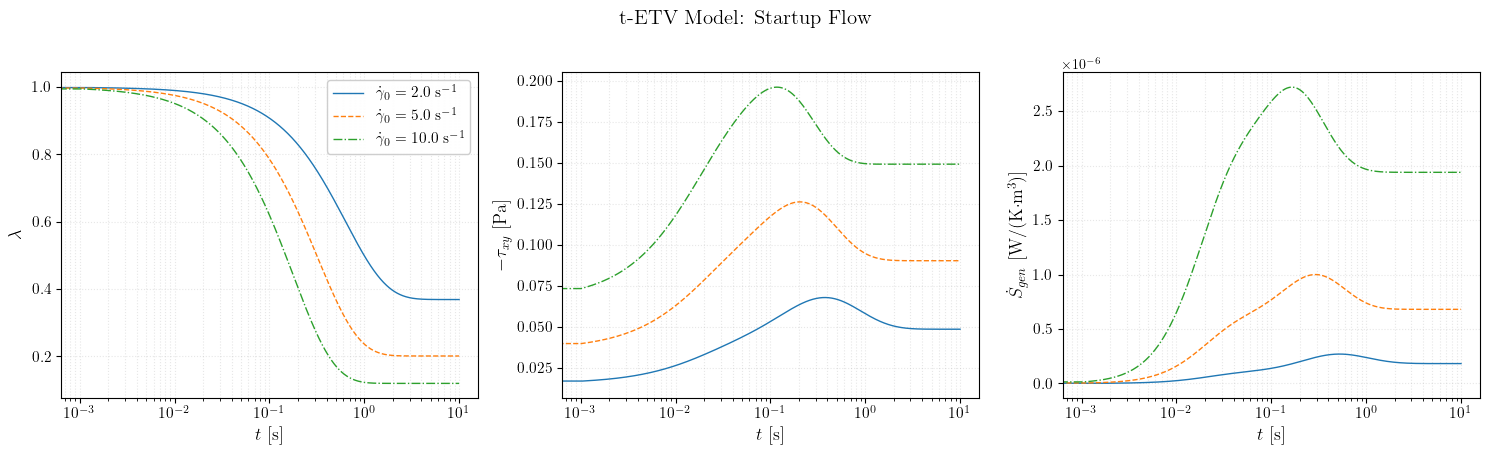

In [16]:
# Define colors and line styles for each shear rate
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green
linestyles = ['-', '--', '-.']
linewidths = [1, 1, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = startup_results[g0]
    label = fr'$\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('t-ETV Model: Startup Flow', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'startup.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/startup.png")
plt.show()

### Stress Relaxation Results

After flow cessation, the system relaxes back to equilibrium. The structure parameter $\lambda$ recovers toward 1 (full aggregation), while the shear stress decays and entropy generation gradually diminishes. These plots show the time evolution across three different pre-shear rates.

In [17]:
t_relax_span = (0.0, 20.0)
t_relax_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(20.0), 999)])
t_relax_eval = np.sort(np.unique(np.clip(t_relax_eval, 0, 20.0)))  # Clip a [0, 20]

relax_results = {}

print("Running stress relaxation...")
for g0 in gamma0_list:
    y_init = startup_results[g0]['y'][:, -1]
    
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, 0.0, params_tuple),
        t_relax_span,
        y_init,
        t_eval=t_relax_eval,
        **INTEGRATOR_OPTS
    )
    
    tauxy = np.array([tauxy_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    
    relax_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ γ̇₀ = {g0} 1/s (relaxation)")

relax_data = {'t': t_relax_eval}
for g0 in gamma0_list:
    r = relax_results[g0]
    relax_data[f'lam_g{g0}'] = r['y'][8, :]
    relax_data[f'tauxy_g{g0}'] = r['tauxy']
    relax_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'relaxation.npz'), **relax_data)
print(f"Saved to {OUTPUT_DIR}/relaxation.npz\n")

Running stress relaxation...
  ✓ γ̇₀ = 2.0 1/s (relaxation)
  ✓ γ̇₀ = 5.0 1/s (relaxation)
  ✓ γ̇₀ = 10.0 1/s (relaxation)
Saved to data/tETV/relaxation.npz



Saved to figs/tETV/relaxation.png


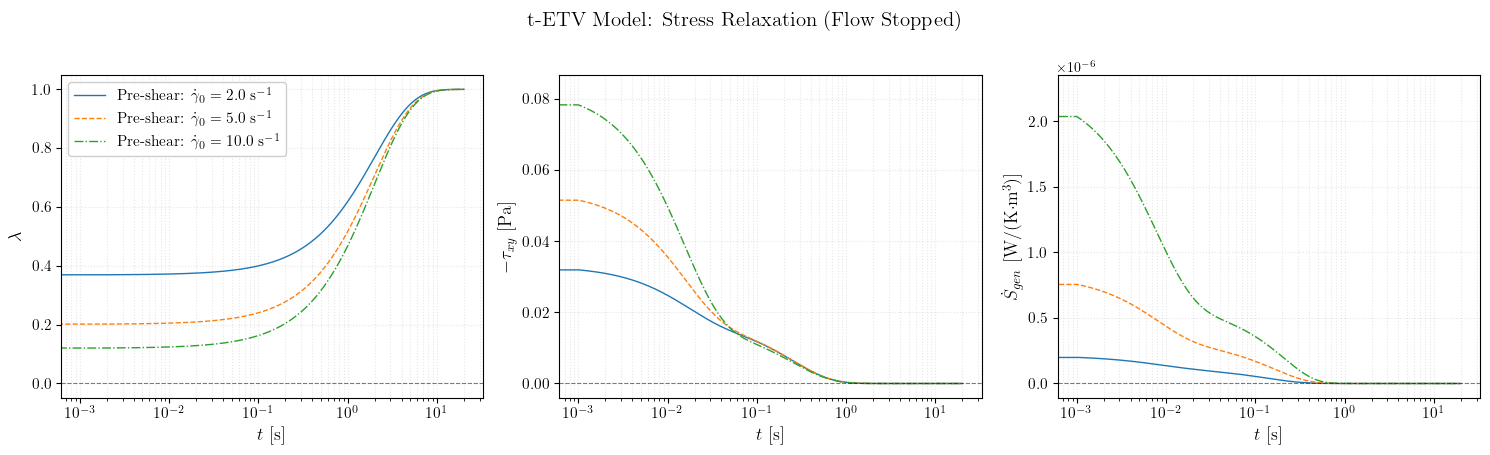

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = relax_results[g0]
    label = fr'Pre-shear: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13)
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13)
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13)

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13)
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('t-ETV Model: Stress Relaxation (Flow Stopped)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'relaxation.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/relaxation.png")
plt.show()

## Protocol 3: Shear Rate Reversal

Shear rate switches from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$ at time $t_{\text{rev}} = 10$ s. Results shown relative to reversal time.

In [19]:
t_rev = 10.0
t_reversal_span = (0.0, 20.0)
t_before = np.logspace(-3, np.log10(t_rev), 500)
t_after = t_rev + np.logspace(-3, np.log10(10.0), 500)
t_reversal_eval = np.concatenate([t_before, t_after])
t_reversal_eval = np.sort(np.unique(np.clip(t_reversal_eval, 0, 20.0)))

reversal_results = {}

print("Running shear rate reversal...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0 if t < t_rev else -g0, params_tuple),
        t_reversal_span,
        y0,
        t_eval=t_reversal_eval,
        **INTEGRATOR_OPTS
    )
    
    # Shear rate history
    gamma_history = np.where(sol.t < t_rev, g0, -g0)
    
    # Compute stress and entropy
    tauxy = np.array([tauxy_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sgen_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    
    # Extract post-reversal data and shift time
    mask = sol.t >= t_rev
    reversal_results[g0] = {
        't': sol.t[mask] - t_rev,
        'y': sol.y[:, mask],
        'tauxy': tauxy[mask],
        'sgen': sgen[mask]
    }
    print(f"  ✓ γ̇₀ = {g0} 1/s (reversed at t={t_rev} s)")

reversal_data = {'t': reversal_results[gamma0_list[0]]['t']}
for g0 in gamma0_list:
    r = reversal_results[g0]
    reversal_data[f'lam_g{g0}'] = r['y'][8, :]
    reversal_data[f'tauxy_g{g0}'] = r['tauxy']
    reversal_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'reversal.npz'), **reversal_data)
print(f"Saved to {OUTPUT_DIR}/reversal.npz\n")

Running shear rate reversal...
  ✓ γ̇₀ = 2.0 1/s (reversed at t=10.0 s)
  ✓ γ̇₀ = 5.0 1/s (reversed at t=10.0 s)
  ✓ γ̇₀ = 10.0 1/s (reversed at t=10.0 s)
Saved to data/tETV/reversal.npz



Saved to figs/tETV/reversal.png


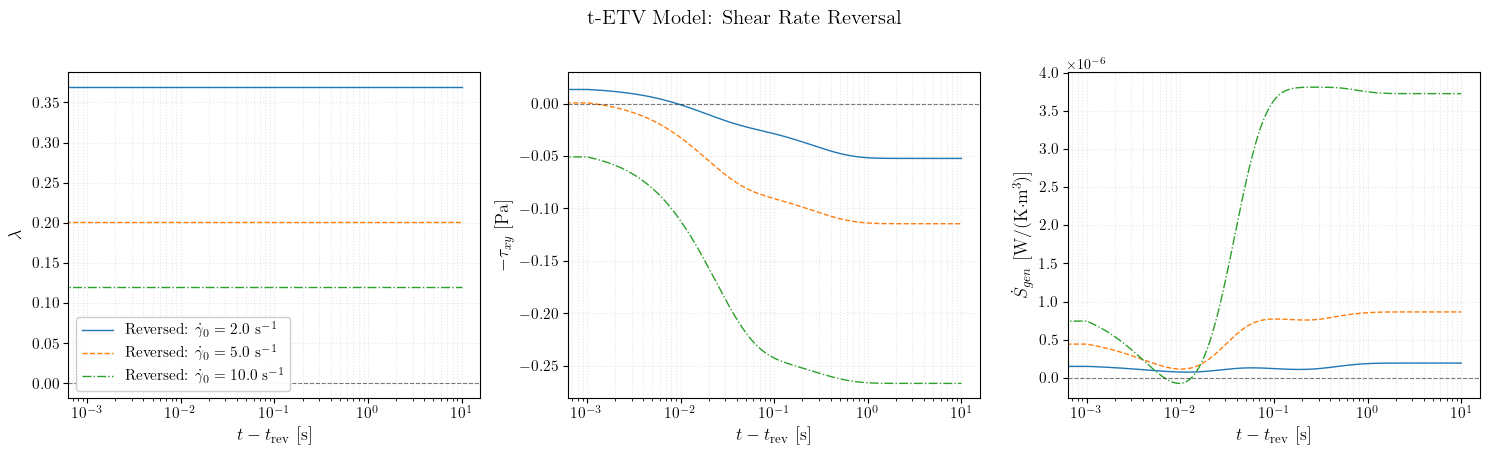

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = reversal_results[g0]
    label = fr'Reversed: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

# Formatting
axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K·m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t - t_{\text{rev}}$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('t-ETV Model: Shear Rate Reversal', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'reversal.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/reversal.png")
plt.show()